In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('../data/crop_dataset.csv')

In [23]:
print(df.head())

     N    P    K  temperature   humidity        ph    rainfall      label
0    7  144  197    23.849401  94.348150  6.133221  114.051249      apple
1   42   25   38    24.684050  30.442382  7.662854   93.871731      jowar
2   80   28   45    31.446877  31.094701  6.545759   72.509749      jowar
3  107   71   55    29.420179  83.967545  6.088064  117.229079     banana
4   50   55   16    28.814607  65.335381  7.581443   62.262425  blackgram


In [24]:
print(df.shape)

(5000, 8)


In [25]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [26]:
print(df.duplicated().sum())

0


In [27]:
df = df.drop_duplicates()

In [28]:
X = df.drop('label', axis=1)
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Train model
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [32]:
lr_pred = lr.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.732


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        22
       bajra       0.81      1.00      0.90        43
      banana       0.68      0.74      0.71        70
   blackgram       0.81      0.85      0.83        20
    cardamom       0.58      0.46      0.51        48
    chickpea       1.00      1.00      1.00        18
     coconut       0.66      0.82      0.73        62
      coffee       0.52      0.50      0.51        58
      cotton       0.67      0.70      0.68        56
      grapes       1.00      1.00      1.00        27
   groundnut       0.88      0.77      0.82        39
       jowar       0.72      0.57      0.63        46
        jute       0.50      0.73      0.59        11
 kidneybeans       1.00      1.00      1.00        23
      lentil       0.79      0.88      0.83        17
       maize       0.59      0.87      0.70        15
       mango       1.00      0.91      0.95        23
   mothbeans       0.88    

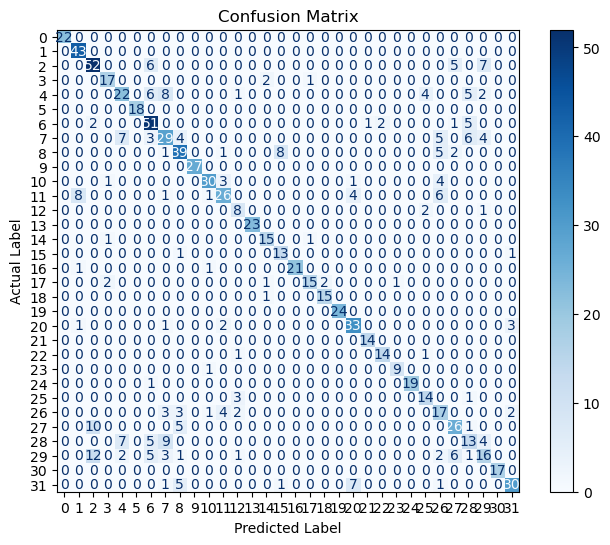

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()